In [137]:
import pandas as pd

In [138]:
df = pd.read_csv("../data/raw/portugal_listinigs.csv")
df.head()

C:\Users\Yan\AppData\Local\Temp\ipykernel_7040\1390978082.py:1: DtypeWarning: Columns (9,10,12,13,14,15,16,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/portugal_listinigs.csv")


,Price,District,City,Town,Type,EnergyCertificate,GrossArea,TotalArea,Parking,HasParking,...,Elevator,ElectricCarsCharging,TotalRooms,NumberOfBedrooms,NumberOfWC,ConservationStatus,LivingArea,LotSize,BuiltArea,NumberOfBathrooms
0,780000.0,Vila Real,Valpaços,Carrazedo de Montenegro e Curros,Farm,NC,200.0,552450.0,0.0,False,...,False,NaN,NaN,NaN,NaN,NaN,120.0,NaN,NaN,0.0
1,223000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,NaN,81.0,1.0,True,...,True,NaN,2.0,NaN,NaN,NaN,81.0,NaN,NaN,2.0
2,228000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,NaN,108.0,1.0,True,...,True,NaN,2.0,NaN,NaN,NaN,108.0,NaN,NaN,2.0
3,250000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,NaN,114.0,1.0,True,...,True,NaN,2.0,NaN,NaN,NaN,114.0,NaN,NaN,0.0
4,250000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,NaN,114.0,1.0,True,...,True,NaN,2.0,NaN,NaN,NaN,114.0,NaN,NaN,2.0


In [139]:
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135536 entries, 0 to 135535
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Price                  135236 non-null  float64
 1   District               135536 non-null  object 
 2   City                   135536 non-null  object 
 3   Town                   135534 non-null  object 
 4   Type                   135520 non-null  object 
 5   EnergyCertificate      135522 non-null  object 
 6   GrossArea              27638 non-null   float64
 7   TotalArea              127153 non-null  float64
 8   Parking                135342 non-null  float64
 9   HasParking             68215 non-null   object 
 10  Floor                  27929 non-null   object 
 11  ConstructionYear       88021 non-null   float64
 12  EnergyEfficiencyLevel  67289 non-null   object 
 13  PublishDate            29239 non-null   object 
 14  Garage                 67289 non-nul

Index(['Price', 'District', 'City', 'Town', 'Type', 'EnergyCertificate',
       'GrossArea', 'TotalArea', 'Parking', 'HasParking', 'Floor',
       'ConstructionYear', 'EnergyEfficiencyLevel', 'PublishDate', 'Garage',
       'Elevator', 'ElectricCarsCharging', 'TotalRooms', 'NumberOfBedrooms',
       'NumberOfWC', 'ConservationStatus', 'LivingArea', 'LotSize',
       'BuiltArea', 'NumberOfBathrooms'],
      dtype='object')

In [140]:
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_percentage = (missing_values / len(df)) * 100

missing_data = pd.DataFrame({"Valores Ausentes": missing_values, "Porcentagem (%)": missing_percentage})

# Ordenar do maior para o menor
missing_data = missing_data.sort_values(by="Porcentagem (%)", ascending=False)

# Exibir os primeiros resultados
print(missing_data)


                       Valores Ausentes  Porcentagem (%)
ConservationStatus               116244        85.766143
BuiltArea                        108919        80.361675
GrossArea                        107898        79.608370
Floor                            107607        79.393667
PublishDate                      106297        78.427134
LotSize                           95953        70.795213
NumberOfBedrooms                  88495        65.292616
NumberOfWC                        78280        57.755873
Garage                            68247        50.353412
EnergyEfficiencyLevel             68247        50.353412
ElectricCarsCharging              68247        50.353412
HasParking                        67321        49.670198
TotalRooms                        62292        45.959745
ConstructionYear                  47515        35.057107
LivingArea                        30584        22.565223
TotalArea                          8383         6.185073
NumberOfBathrooms              

In [141]:
# Definir o limite de 78% de valores nulos
threshold = 0.78 * len(df)

# Identificar colunas a serem removidas
cols_to_drop = df.columns[df.isnull().sum() > threshold]

# Remover as colunas
df_cleaned = df.drop(columns=cols_to_drop)

# Exibir as colunas restantes
df_cleaned.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135536 entries, 0 to 135535
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Price                  135236 non-null  float64
 1   District               135536 non-null  object 
 2   City                   135536 non-null  object 
 3   Town                   135534 non-null  object 
 4   Type                   135520 non-null  object 
 5   EnergyCertificate      135522 non-null  object 
 6   TotalArea              127153 non-null  float64
 7   Parking                135342 non-null  float64
 8   HasParking             68215 non-null   object 
 9   ConstructionYear       88021 non-null   float64
 10  EnergyEfficiencyLevel  67289 non-null   object 
 11  Garage                 67289 non-null   object 
 12  Elevator               135504 non-null  object 
 13  ElectricCarsCharging   67289 non-null   object 
 14  TotalRooms             73244 non-nul

In [142]:
# Removendo as linhas que o preço é nulo

# Remover linhas onde a coluna "Price" está vazia
df_cleaned = df_cleaned.dropna(subset=["Price"])

# Verificar se ainda existem valores nulos na coluna "Price"
df_cleaned["Price"].isnull().sum()


np.int64(0)

In [143]:
missing_values_cleaned = df_cleaned.isnull().sum().sort_values(ascending=False)

missing_percentage = (missing_values_cleaned / len(df_cleaned)) * 100

missing_data = pd.DataFrame({"Valores Ausentes": missing_values_cleaned, "Porcentagem (%)": missing_percentage})

# Ordenar do maior para o menor
missing_data = missing_data.sort_values(by="Porcentagem (%)", ascending=False)

# Exibir os primeiros resultados
print(missing_data)

                       Valores Ausentes  Porcentagem (%)
LotSize                           95737        70.792540
NumberOfBedrooms                  88328        65.313970
NumberOfWC                        78138        57.778994
EnergyEfficiencyLevel             68107        50.361590
ElectricCarsCharging              68107        50.361590
Garage                            68107        50.361590
HasParking                        67161        49.662072
TotalRooms                        62178        45.977402
ConstructionYear                  47370        35.027655
LivingArea                        30553        22.592357
TotalArea                          8377         6.194357
NumberOfBathrooms                  6834         5.053388
Parking                             194         0.143453
Elevator                             32         0.023662
Type                                 16         0.011831
EnergyCertificate                    14         0.010352
Town                           

In [144]:
# Verificar os valores únicos da coluna "Type" e sua contagem
type_counts = df_cleaned["Type"].value_counts()

# Exibir os tipos de imóveis e suas quantidades
type_counts

Type
Apartment              47236
House                  36652
Land                   31820
Store                   5325
Farm                    3883
Building                2482
Transfer of lease       1636
Warehouse               1441
Garage                   976
Other - Commercial       814
Office                   725
Other - Residential      599
Industrial               440
Duplex                   385
Investment               255
Storage                  203
Hotel                    159
Studio                    87
Estate                    64
Mansion                   31
Manor                      7
Name: count, dtype: int64

In [145]:
# Definir os tipos de imóveis residenciais
residential_types = ["Apartment", "House", "Duplex", "Studio", "Mansion", "Manor"]

# Criar um novo DataFrame contendo apenas esses tipos de imóveis
df_residential = df_cleaned[df_cleaned["Type"].isin(residential_types)]

# Exibir informações do novo dataset filtrado
df_residential.info()


<class 'pandas.core.frame.DataFrame'>
Index: 84398 entries, 1 to 135534
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Price                  84398 non-null  float64
 1   District               84398 non-null  object 
 2   City                   84398 non-null  object 
 3   Town                   84398 non-null  object 
 4   Type                   84398 non-null  object 
 5   EnergyCertificate      84398 non-null  object 
 6   TotalArea              84389 non-null  float64
 7   Parking                84260 non-null  float64
 8   HasParking             42497 non-null  object 
 9   ConstructionYear       71568 non-null  float64
 10  EnergyEfficiencyLevel  41892 non-null  object 
 11  Garage                 41892 non-null  object 
 12  Elevator               84389 non-null  object 
 13  ElectricCarsCharging   41892 non-null  object 
 14  TotalRooms             62995 non-null  float64
 15  Number

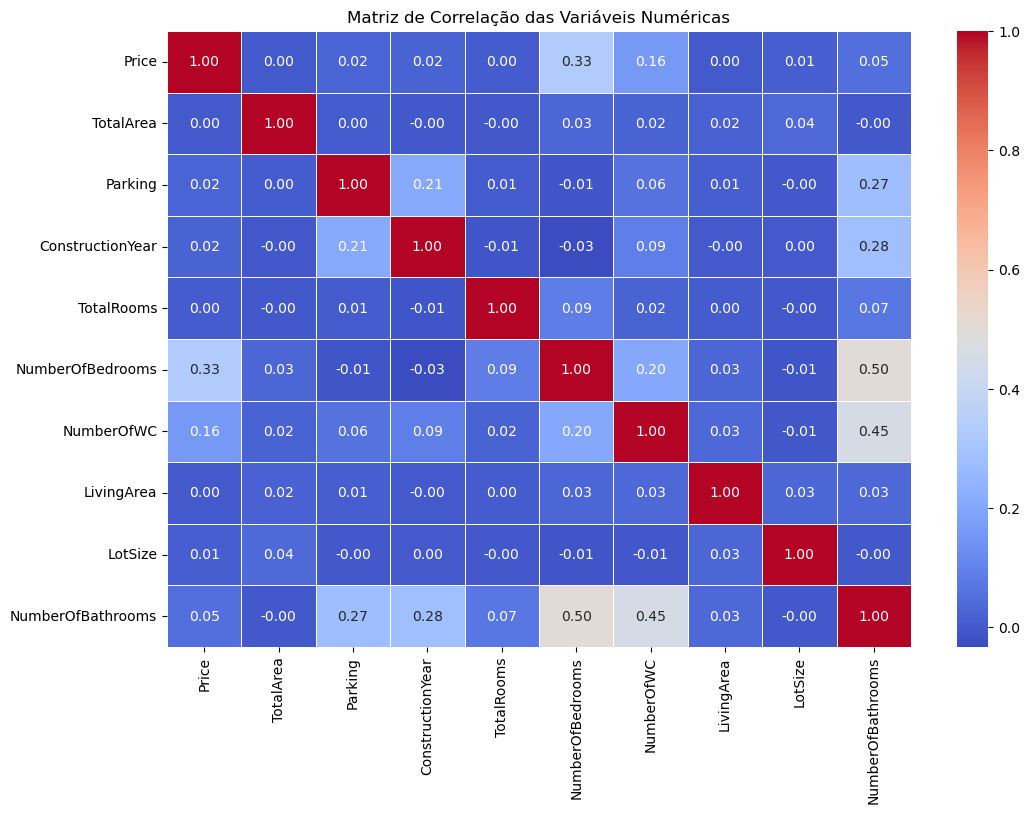

In [146]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selecionar apenas colunas numéricas para evitar erro
df_numeric = df_residential.select_dtypes(include=["number"])

# Criar a matriz de correlação
correlation_matrix = df_numeric.corr()

# Ajustar o tamanho da figura
plt.figure(figsize=(12, 8))

# Criar o heatmap de correlação
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

# Título do gráfico
plt.title("Matriz de Correlação das Variáveis Numéricas")

# Exibir o gráfico
plt.show()



In [147]:
df_residential.to_csv("../data/processed/portugal_cleaned.csv", index=False)
